Codigo de Prueba

In [2]:
#Instalar Librerias

!pip install pandas
!pip install numpy
!pip install -U scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install missingno
!pip install xgboost
!pip install streamlit

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   -------------------- ------------------- 5.2/10.2 MB 66.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.8/10.2 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 21.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/731.2 kB ? eta -:--:--
   --------------------------------------- 731.2/731.2 kB 33.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/26.1 MB ? eta -:--:--
   ---------------------- ----------------- 14.4/26.1 MB 70.7 MB/s eta 0:00:01
   ---------------------------------------  26.0/26.1 MB 71.2 MB/s eta 0:00:01
   ---------------------------------------- 26.1/26.1 MB 56.2 MB/s eta 0:00:00
   ---------------------------------------- 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import xgboost as xgb
from xgboost import XGBRegressor

In [3]:
data = pd.read_csv("data\db_measurements_v2.1.0.csv.gz")
data

C:\Users\diego\AppData\Local\Temp\ipykernel_11104\441277053.py:1: DtypeWarning: Columns (5,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data\db_measurements_v2.1.0.csv.gz")


,index,record_id,building_id,timestamp,season,subject_id,age,gender,ht,wt,...,t_out,rh_out,t_out_isd,rh_out_isd,set,pmv,ppd,pmv_ce,ppd_ce,t_mot_isd
0,0,1,1,1995-05-18T00:00:00Z,winter,10.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,28.1,0.50,10.2,0.38,8.0,17.4
1,1,2,1,1995-05-18T00:00:00Z,winter,14.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,27.2,0.40,8.4,0.40,8.4,17.4
2,2,3,1,1995-05-18T00:00:00Z,winter,15.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,24.8,-0.07,5.1,-0.07,5.1,17.4
3,3,4,1,1995-05-18T00:00:00Z,winter,17.0,NaN,female,NaN,NaN,...,15.86,99.1,16.295833,86.837514,25.5,0.31,7.0,0.14,5.4,17.4
4,4,5,1,1995-05-18T00:00:00Z,winter,21.0,NaN,male,NaN,NaN,...,15.86,99.1,16.295833,86.837514,26.0,0.05,5.0,-0.06,5.1,17.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,110065,110066,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109029,110066,110067,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109030,110067,110068,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0
109031,110068,110069,809,2014-06-02T00:00:00Z,hot/wet,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,28.316667,82.059739,NaN,NaN,NaN,NaN,NaN,28.0


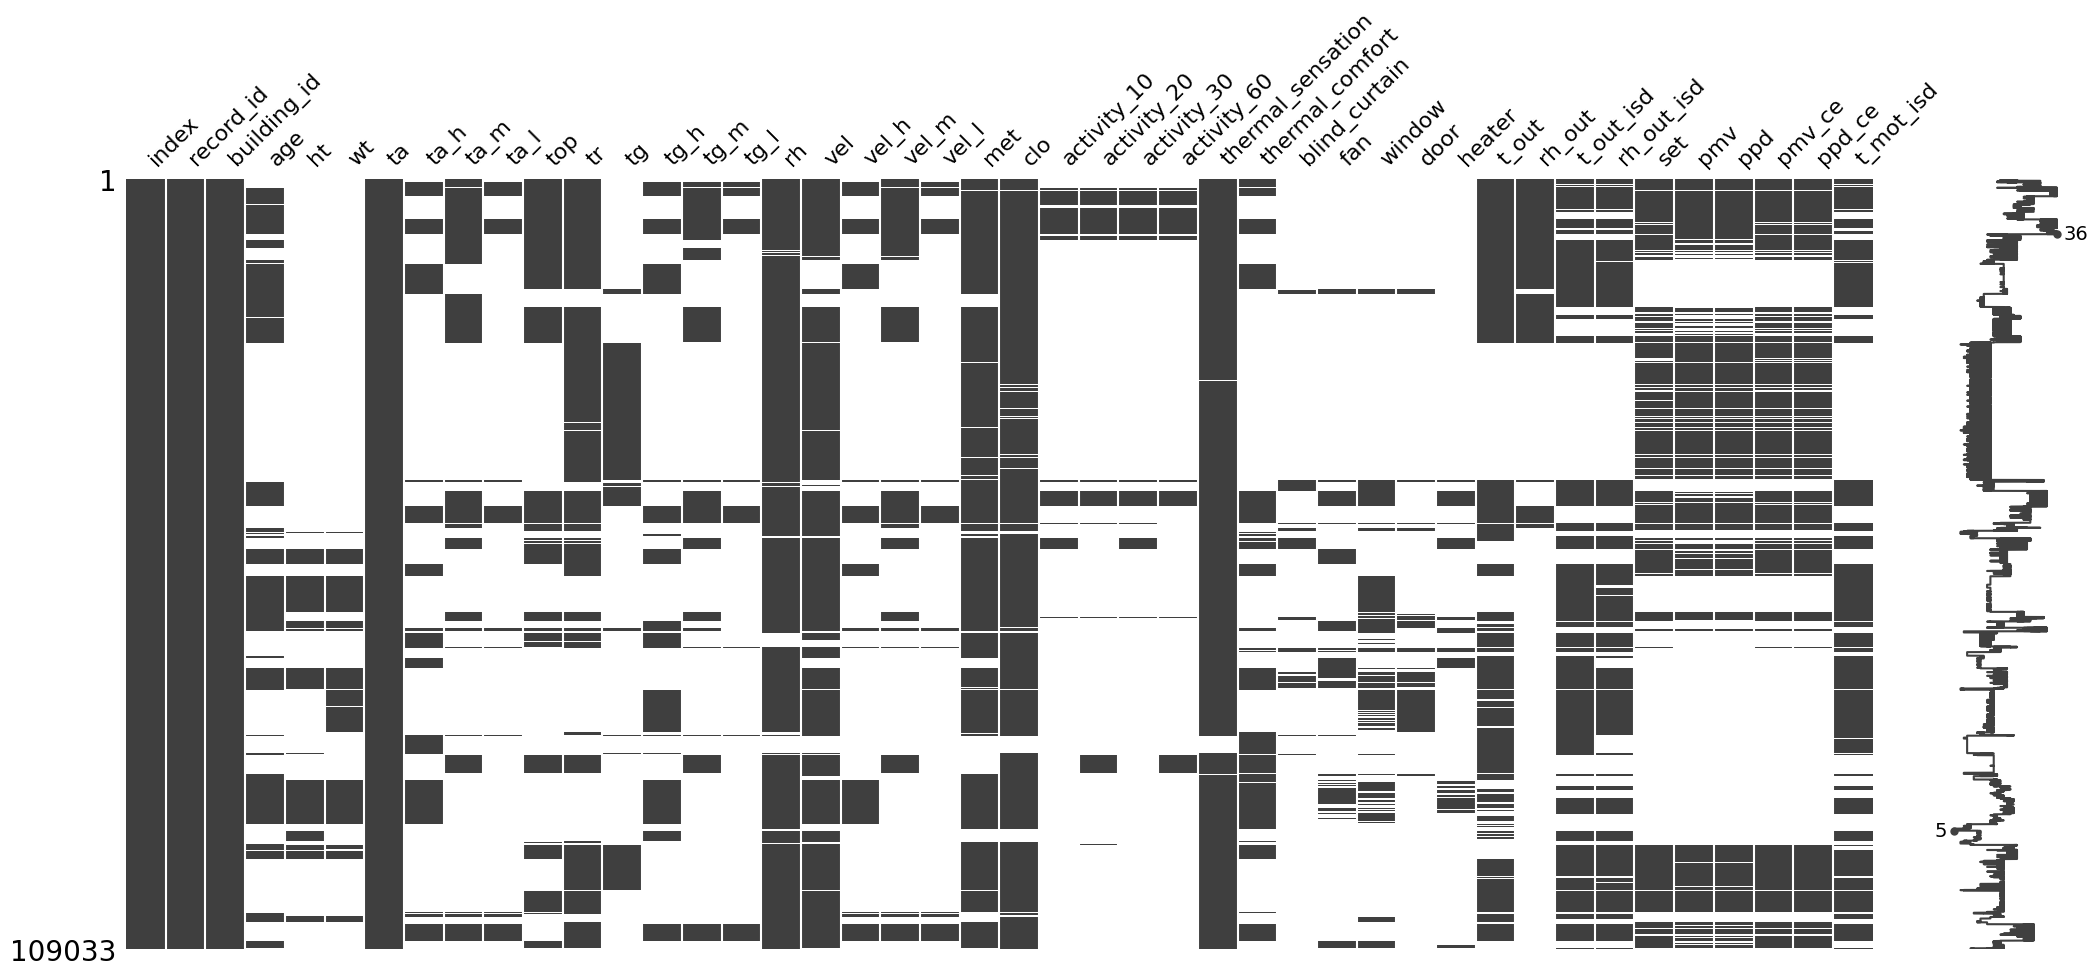

In [4]:
msno.matrix(data.select_dtypes(include='number'));

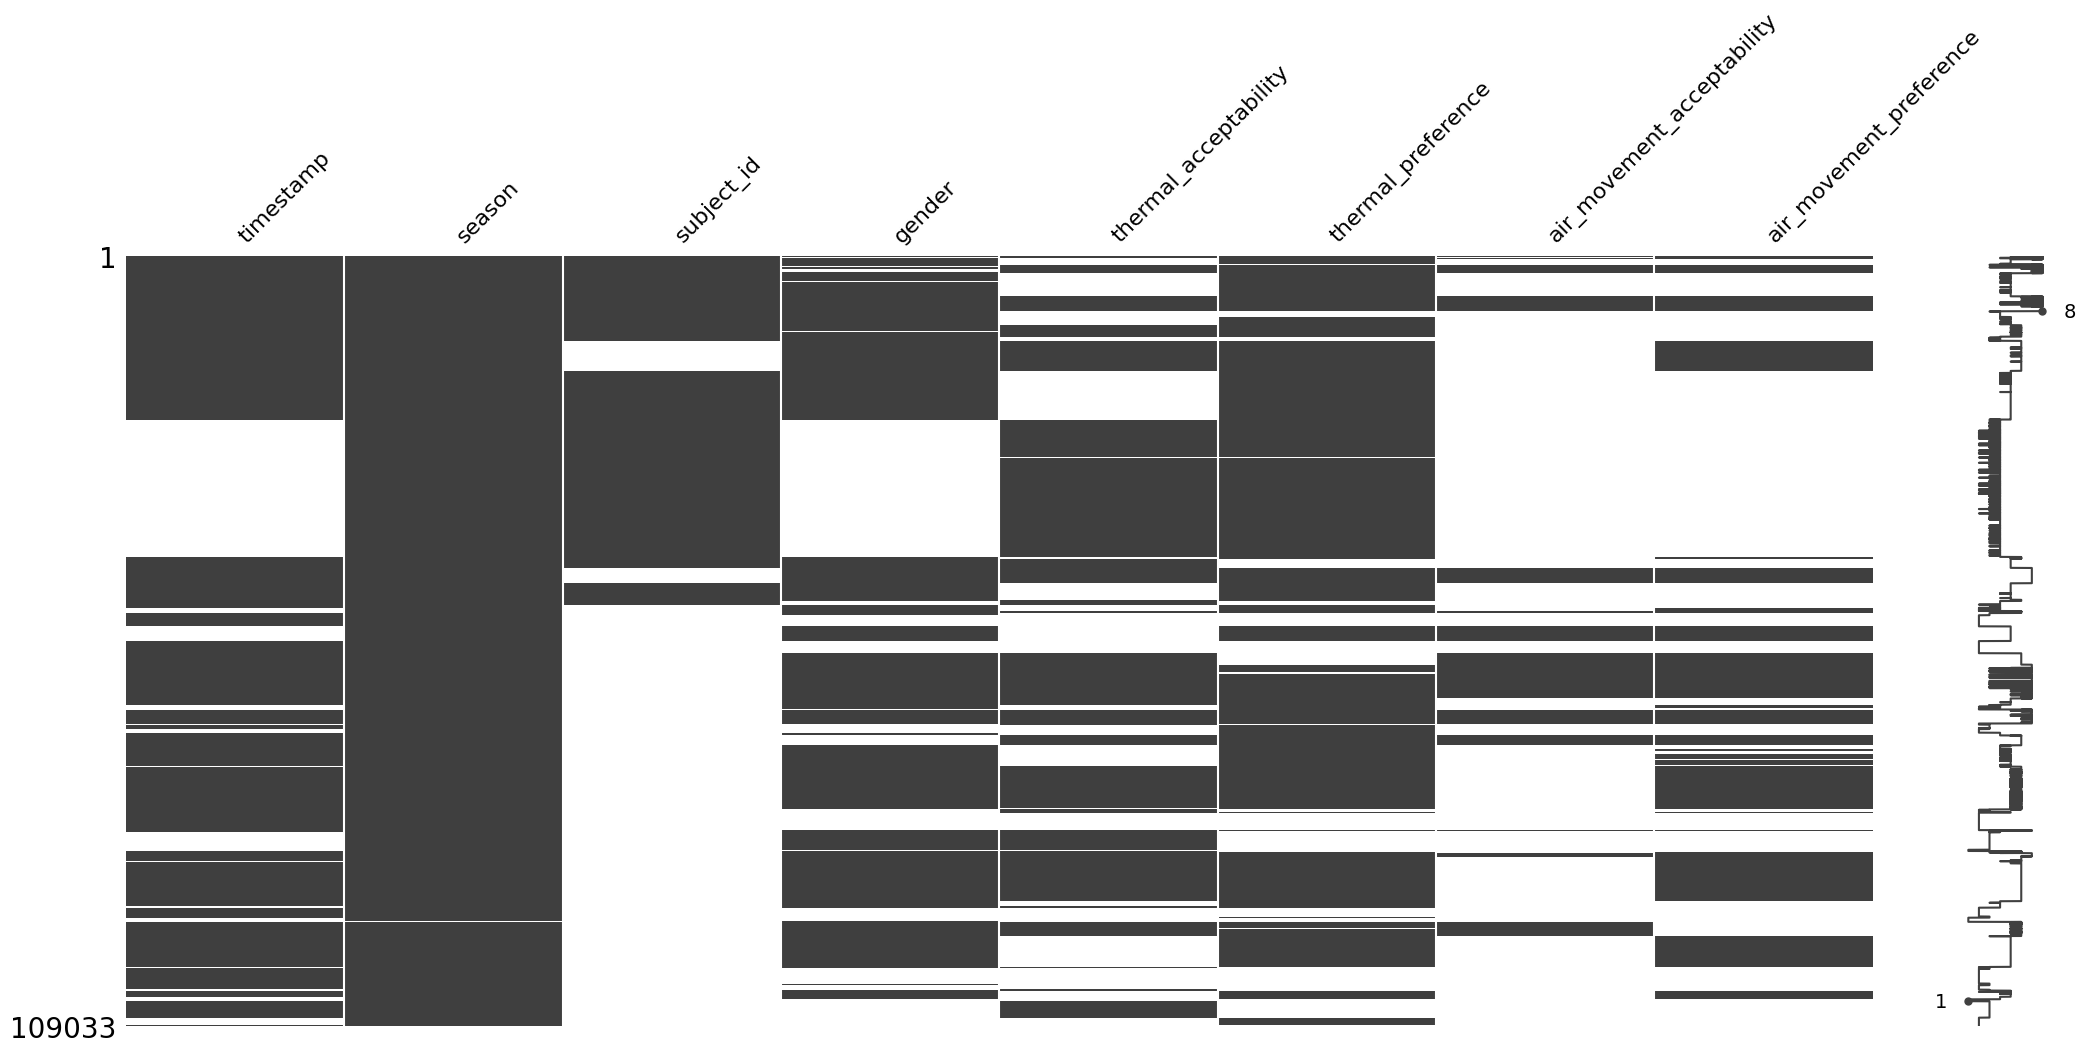

In [5]:
msno.matrix(data.select_dtypes(include='O'));

In [6]:
fil_data = data[['ta','tr','rh','vel','met','clo','thermal_sensation','blind_curtain','fan','window','door','heater','pmv_ce']].copy()
fil_data

,ta,tr,rh,vel,met,clo,thermal_sensation,blind_curtain,fan,window,door,heater,pmv_ce
0,22.3,22.950000,61.0,0.03,1.706485,0.95,2.0,NaN,NaN,NaN,NaN,NaN,0.38
1,23.0,24.134286,59.0,0.08,1.109215,1.07,2.0,NaN,NaN,NaN,NaN,NaN,0.40
2,22.0,22.091429,61.0,0.04,1.211604,0.88,0.0,NaN,NaN,NaN,NaN,NaN,-0.07
3,23.2,24.330303,58.0,0.03,1.774744,0.59,0.0,NaN,NaN,NaN,NaN,NaN,0.14
4,22.2,23.077143,62.0,0.15,1.484642,0.83,0.0,NaN,NaN,NaN,NaN,NaN,-0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109028,27.6,NaN,64.0,NaN,1.100000,0.64,0.0,NaN,NaN,NaN,NaN,NaN,NaN
109029,28.3,NaN,66.0,NaN,1.100000,0.79,1.0,NaN,NaN,NaN,NaN,NaN,NaN
109030,28.3,NaN,66.0,NaN,1.100000,0.62,3.0,NaN,NaN,NaN,NaN,NaN,NaN
109031,28.3,NaN,66.0,NaN,1.200000,0.57,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
fil_data['met'] = fil_data['met'].fillna(data['met'].mean())
fil_data['clo'] = fil_data['clo'].fillna(data['clo'].mean())
fil_data['pmv_ce'] = fil_data['pmv_ce'].fillna(data['pmv_ce'].mean())
fil_data['thermal_sensation'] = fil_data['thermal_sensation'].fillna(data['thermal_sensation'].mean())

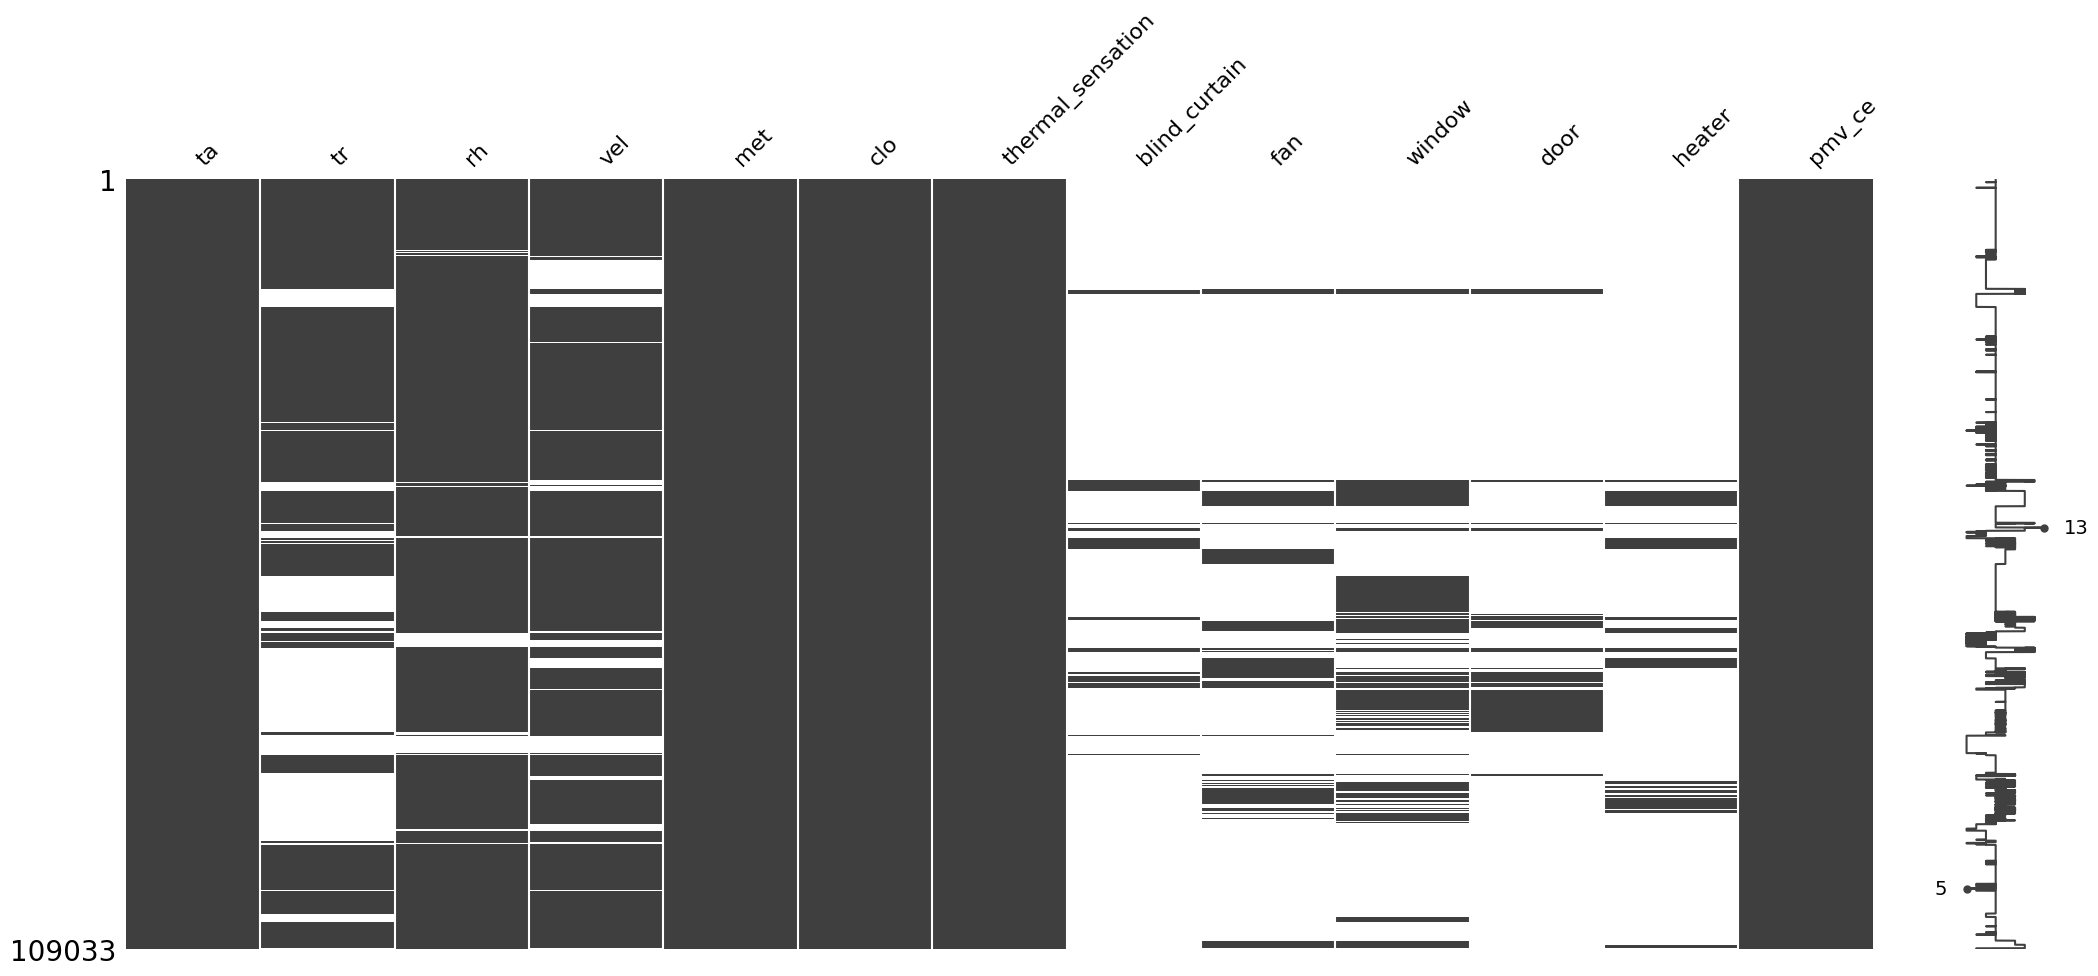

In [8]:
msno.matrix(fil_data.select_dtypes(include='number'));

In [9]:
study_data = fil_data.loc[:,["ta","tr","rh","vel","met","clo","pmv_ce"]]
study_data

,ta,tr,rh,vel,met,clo,pmv_ce
0,22.3,22.950000,61.0,0.03,1.706485,0.95,0.380000
1,23.0,24.134286,59.0,0.08,1.109215,1.07,0.400000
2,22.0,22.091429,61.0,0.04,1.211604,0.88,-0.070000
3,23.2,24.330303,58.0,0.03,1.774744,0.59,0.140000
4,22.2,23.077143,62.0,0.15,1.484642,0.83,-0.060000
...,...,...,...,...,...,...,...
109028,27.6,NaN,64.0,NaN,1.100000,0.64,-0.118738
109029,28.3,NaN,66.0,NaN,1.100000,0.79,-0.118738
109030,28.3,NaN,66.0,NaN,1.100000,0.62,-0.118738
109031,28.3,NaN,66.0,NaN,1.200000,0.57,-0.118738


In [10]:
study_data = study_data.dropna().reset_index(drop=True)
study_data

,ta,tr,rh,vel,met,clo,pmv_ce
0,22.3,22.950000,61.0,0.03,1.706485,0.95,0.38
1,23.0,24.134286,59.0,0.08,1.109215,1.07,0.40
2,22.0,22.091429,61.0,0.04,1.211604,0.88,-0.07
3,23.2,24.330303,58.0,0.03,1.774744,0.59,0.14
4,22.2,23.077143,62.0,0.15,1.484642,0.83,-0.06
...,...,...,...,...,...,...,...
63333,20.1,20.900000,65.0,0.04,1.100000,0.88,-0.58
63334,20.1,20.700000,65.0,0.04,1.000000,0.87,-0.94
63335,20.3,20.900000,67.0,0.02,1.000000,0.76,-1.14
63336,20.3,20.900000,67.0,0.02,1.300000,0.71,-0.55


In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
X = study_data[["ta","tr","rh","vel","met","clo"]]

y = study_data["pmv_ce"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)


# LINEAR REGRESSOR RIDGE

In [13]:
# 1. Escalar los datos (importante para Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# 2. Crear y entrenar el modelo Ridge
ridge_model = Ridge(alpha=1.0, random_state=11)
ridge_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,11


In [15]:
# 3. Hacer predicciones
y_pred_train = ridge_model.predict(X_train_scaled)
y_pred_test = ridge_model.predict(X_test_scaled)

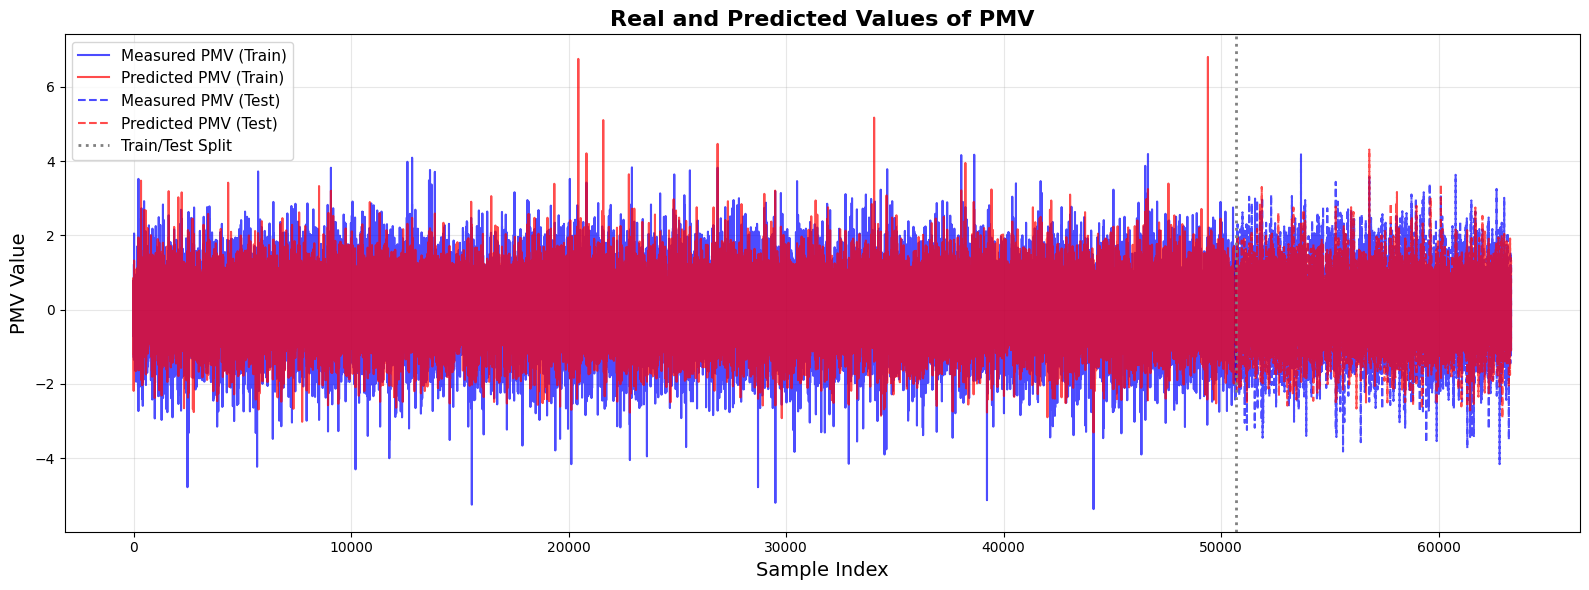

=== Model Performance ===

Train Set:
  MAE:  0.2414
  RMSE: 0.3816
  R²:   0.7327

Test Set:
  MAE:  0.2425
  RMSE: 0.3743
  R²:   0.7510


In [16]:
# ...existing code...
# 4. Visualización: PMV Real vs Predicho (Train + Test combinados)
fig, ax = plt.subplots(figsize=(16, 6))

# Crear índices continuos
train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

# Plot train set
ax.plot(train_indices, y_train.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

# Plot test set
ax.plot(test_indices, y_test.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

# Línea vertical separando train/test
ax.axvline(x=len(y_train), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

# Configuración
ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas
print("=== Model Performance ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"  R²:   {r2_score(y_train, y_pred_train):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"  R²:   {r2_score(y_test, y_pred_test):.4f}")
# ...existing code...

In [17]:
X1 = study_data[["ta","tr","rh","vel"]]
y = study_data["pmv_ce"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y, test_size=0.2, random_state=11)

In [18]:
# 1. Escalar los datos (importante para Ridge)
scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train1)
X_test_scaled1 = scaler.transform(X_test1)

In [19]:
# 2. Crear y entrenar el modelo Ridge
ridge_model1 = Ridge(alpha=1.0, random_state=11)
ridge_model1.fit(X_train_scaled1, y_train1)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,11


In [20]:
# 3. Hacer predicciones
y_pred_train1 = ridge_model1.predict(X_train_scaled1)
y_pred_test1 = ridge_model1.predict(X_test_scaled1)

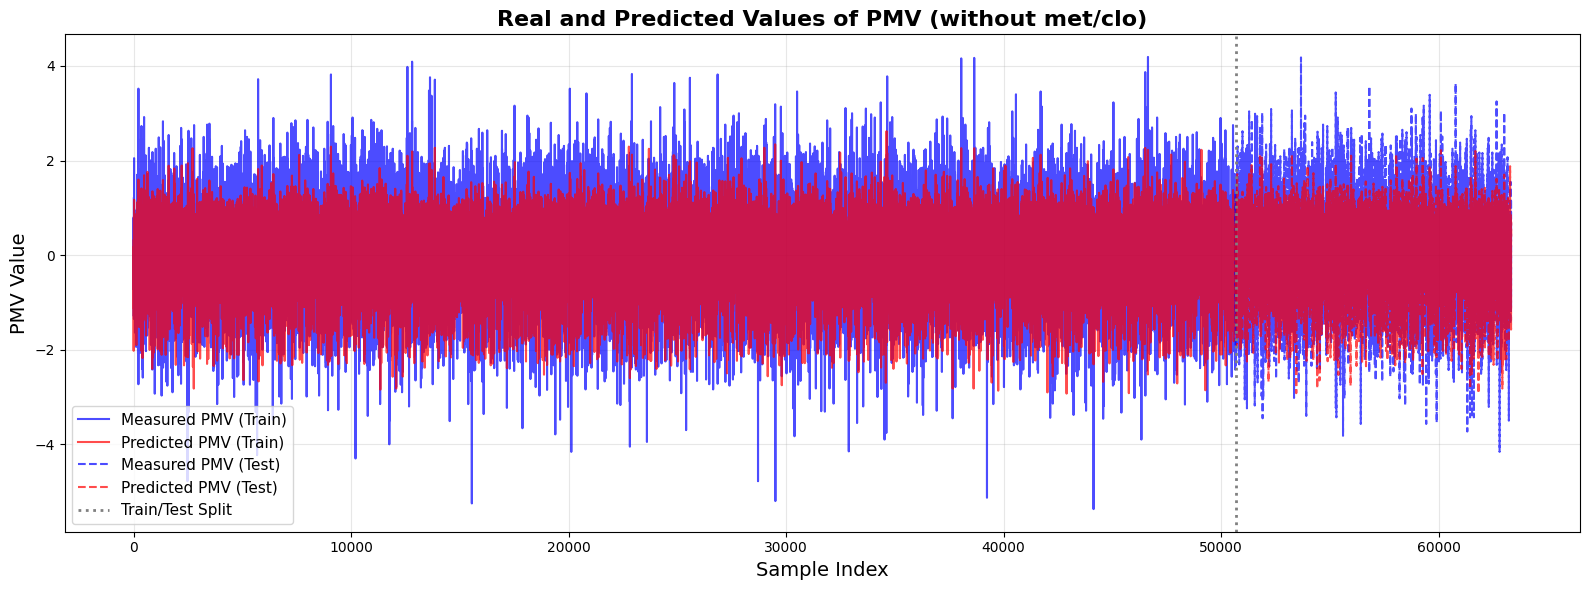

=== Model Performance (without met/clo) ===

Train Set:
  MAE:  0.3763
  RMSE: 0.5122
  R²:   0.5183

Test Set:
  MAE:  0.3818
  RMSE: 0.5188
  R²:   0.5216


In [21]:
# ...existing code...
# 4. Visualización: PMV Real vs Predicho para modelo sin met/clo
fig, ax = plt.subplots(figsize=(16, 6))

# Crear índices continuos
train_indices = range(len(y_train1))
test_indices = range(len(y_train1), len(y_train1) + len(y_test1))

# Plot train set
ax.plot(train_indices, y_train1.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train1, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

# Plot test set
ax.plot(test_indices, y_test1.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test1, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

# Línea vertical separando train/test
ax.axvline(x=len(y_train1), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

# Configuración
ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV (without met/clo)', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas
print("=== Model Performance (without met/clo) ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train1, y_pred_train1):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train1, y_pred_train1)):.4f}")
print(f"  R²:   {r2_score(y_train1, y_pred_train1):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test1, y_pred_test1):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_test1)):.4f}")
print(f"  R²:   {r2_score(y_test1, y_pred_test1):.4f}")
# ...existing code...

# RF - RANDOM FOREST

In [22]:
# 1. Crear y entrenar el modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,      # Número de árboles
    max_depth=8,        # Profundidad máxima (None = sin límite)
    min_samples_split=20,   # Mínimo de muestras para dividir un nodo
    min_samples_leaf=10,    # Mínimo de muestras en hoja
    max_features='sqrt',
    random_state=11,
    n_jobs=-1              # Usar todos los cores disponibles
)

In [23]:
# 2. Entrenar el modelo (Random Forest no necesita escalado)
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# 3. Hacer predicciones
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

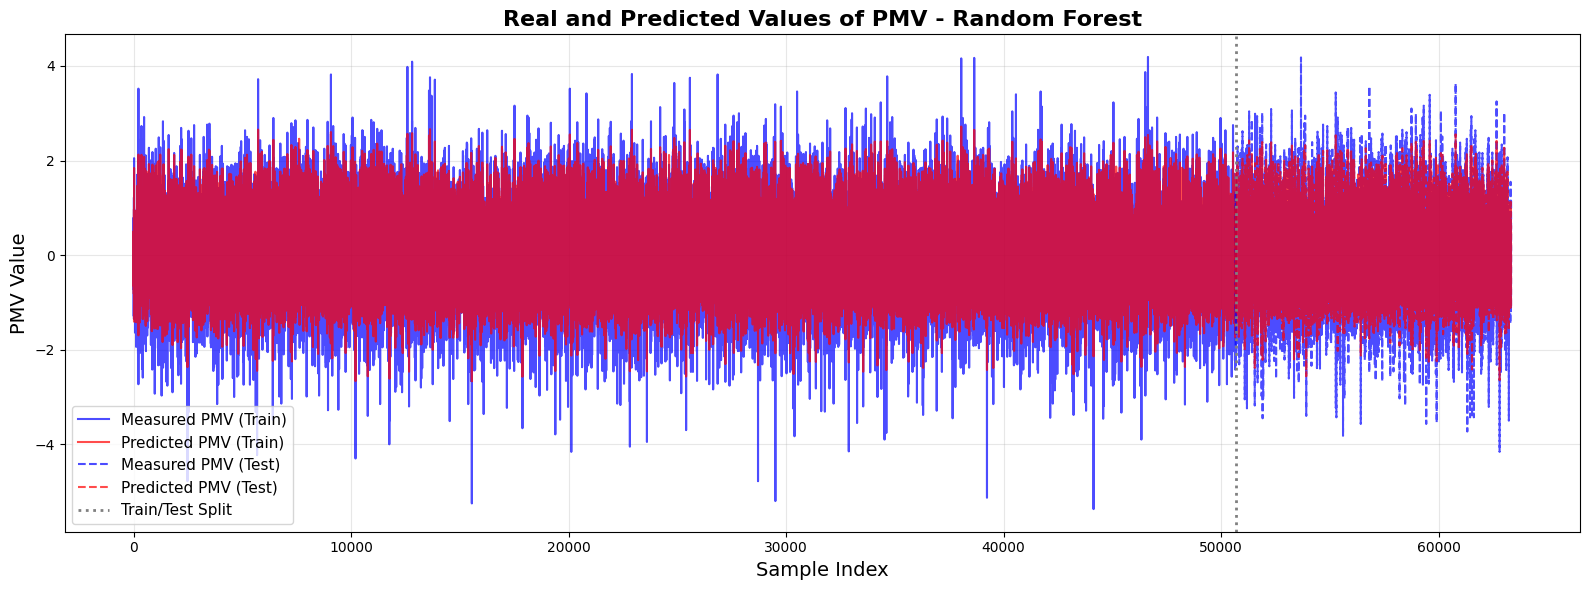

=== Random Forest Performance ===

Train Set:
  MAE:  0.1768
  RMSE: 0.2485
  R²:   0.8867

Test Set:
  MAE:  0.1785
  RMSE: 0.2513
  R²:   0.8877

=== Feature Importance ===
  Feature  Importance
0      ta    0.353112
1      tr    0.341791
5     clo    0.129207
4     met    0.092874
3     vel    0.066166
2      rh    0.016850


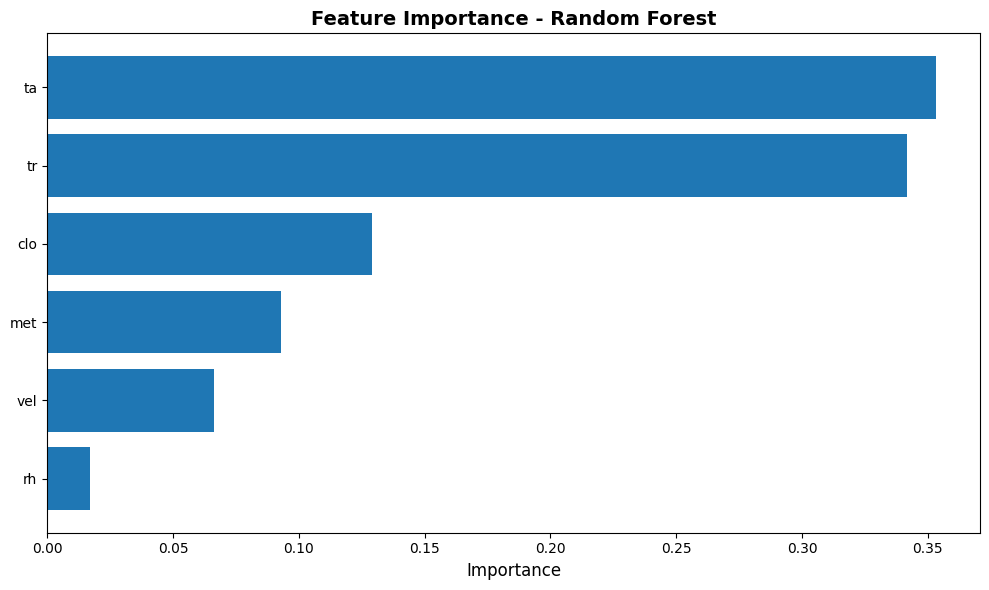

In [25]:
# 4. Visualización
fig, ax = plt.subplots(figsize=(16, 6))

train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

ax.plot(train_indices, y_train.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train_rf, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

ax.plot(test_indices, y_test.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test_rf, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

ax.axvline(x=len(y_train), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV - Random Forest', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Métricas
print("=== Random Forest Performance ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf)):.4f}")
print(f"  R²:   {r2_score(y_train, y_pred_train_rf):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):.4f}")
print(f"  R²:   {r2_score(y_test, y_pred_test_rf):.4f}")

# 6. Importancia de features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'], feature_importance['Importance'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# 1. Crear y entrenar el modelo Random Forest
rf_model1 = RandomForestRegressor(
    n_estimators=200,      # Número de árboles
    max_depth=8,        # Profundidad máxima (None = sin límite)
    min_samples_split=20,   # Mínimo de muestras para dividir un nodo
    min_samples_leaf=10,    # Mínimo de muestras en hoja
    max_features='sqrt',
    random_state=11,
    n_jobs=-1              # Usar todos los cores disponibles
)

In [27]:
# 2. Entrenar el modelo (Random Forest no necesita escalado)
rf_model1.fit(X_train1, y_train1)

,n_estimators,200
,criterion,'squared_error'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# 3. Hacer predicciones
y_pred_train_rf = rf_model1.predict(X_train1)
y_pred_test_rf = rf_model1.predict(X_test1)

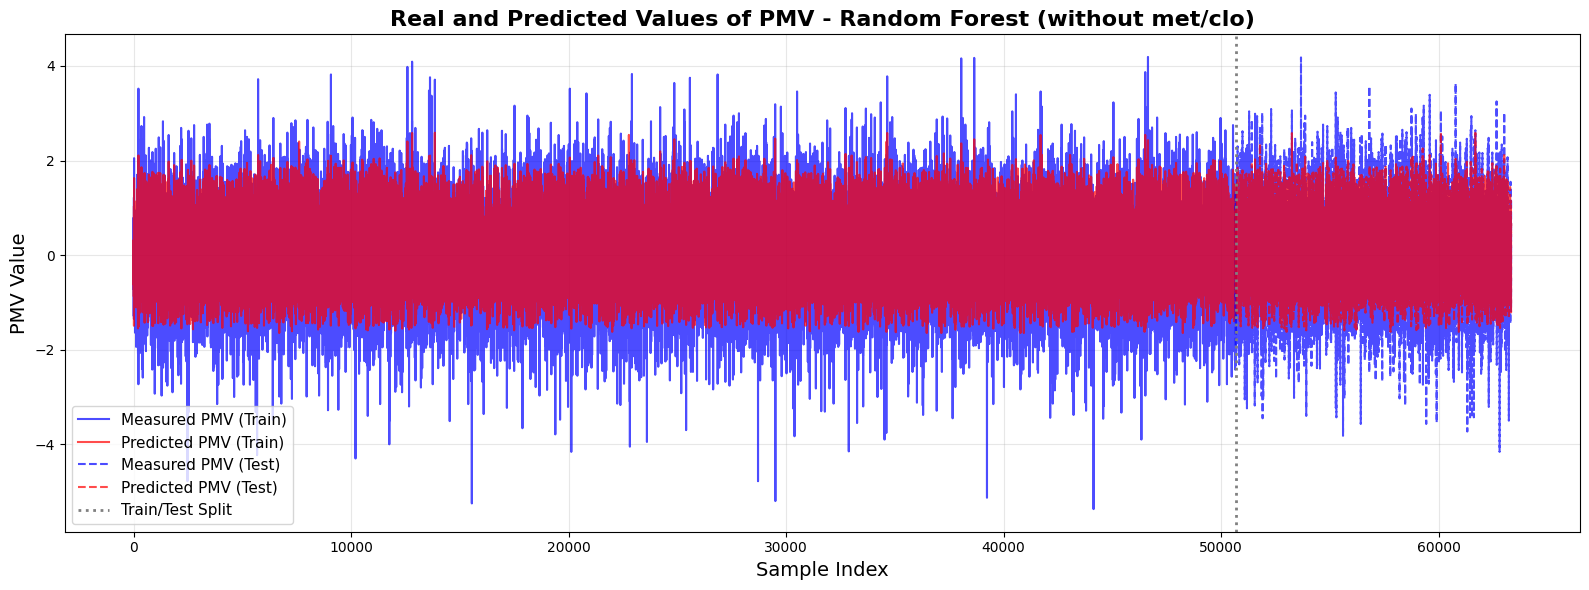

=== Random Forest Performance (without met/clo) ===

Train Set:
  MAE:  0.3126
  RMSE: 0.4294
  R²:   0.6615

Test Set:
  MAE:  0.3198
  RMSE: 0.4400
  R²:   0.6559

=== Feature Importance ===
  Feature  Importance
1      tr    0.456212
0      ta    0.373769
3     vel    0.135519
2      rh    0.034500


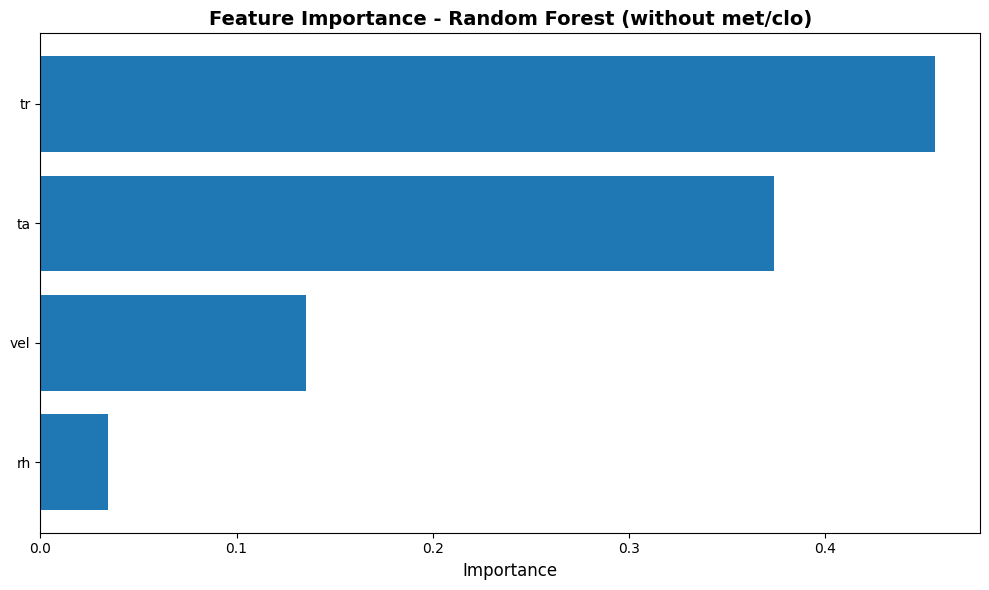

In [29]:
# 4. Visualización Random Forest sin met/clo
fig, ax = plt.subplots(figsize=(16, 6))

train_indices = range(len(y_train1))
test_indices = range(len(y_train1), len(y_train1) + len(y_test1))

ax.plot(train_indices, y_train1.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train_rf, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

ax.plot(test_indices, y_test1.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test_rf, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

ax.axvline(x=len(y_train1), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV - Random Forest (without met/clo)', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Métricas
print("=== Random Forest Performance (without met/clo) ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train1, y_pred_train_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train1, y_pred_train_rf)):.4f}")
print(f"  R²:   {r2_score(y_train1, y_pred_train_rf):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test1, y_pred_test_rf):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_test_rf)):.4f}")
print(f"  R²:   {r2_score(y_test1, y_pred_test_rf):.4f}")

# 6. Importancia de features
feature_importance1 = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': rf_model1.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance1)

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance1['Feature'], feature_importance1['Importance'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance - Random Forest (without met/clo)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# XG BOOST REGRESSOR

In [30]:
# 1. Crear y entrenar el modelo XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,           # Número de árboles
    max_depth=6,                # Profundidad máxima
    learning_rate=0.05,         # Tasa de aprendizaje (eta)
    subsample=0.8,              # Proporción de muestras por árbol
    colsample_bytree=0.8,       # Proporción de features por árbol
    min_child_weight=5,         # Mínimo peso en nodo hijo
    gamma=0.1,                  # Mínima reducción de pérdida para split
    reg_alpha=0.1,              # Regularización L1
    reg_lambda=1.0,             # Regularización L2
    random_state=11,
    n_jobs=-1
)


In [31]:
# 2. Entrenar el modelo
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
# 3. Hacer predicciones
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

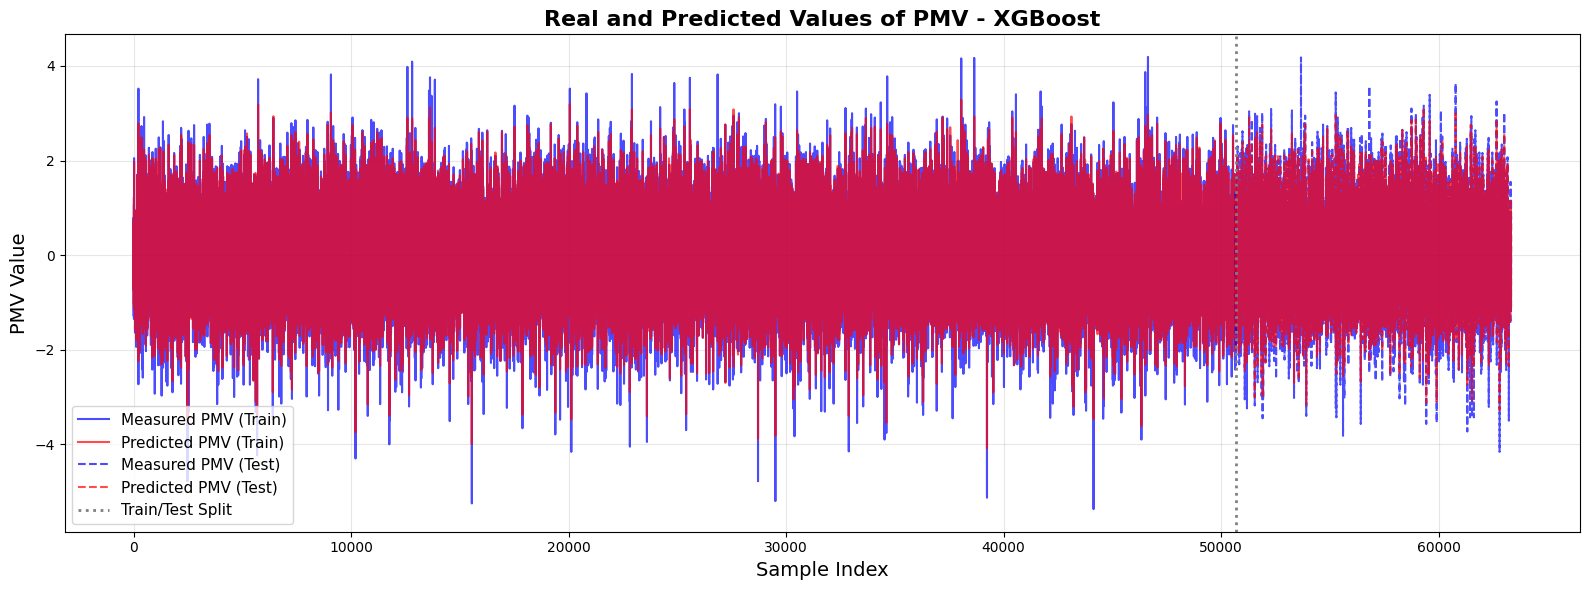

=== XGBoost Performance ===

Train Set:
  MAE:  0.0930
  RMSE: 0.1417
  R²:   0.9632

Test Set:
  MAE:  0.0955
  RMSE: 0.1477
  R²:   0.9612

=== Feature Importance ===
  Feature  Importance
1      tr    0.366812
0      ta    0.289434
5     clo    0.123145
4     met    0.107624
3     vel    0.088342
2      rh    0.024642


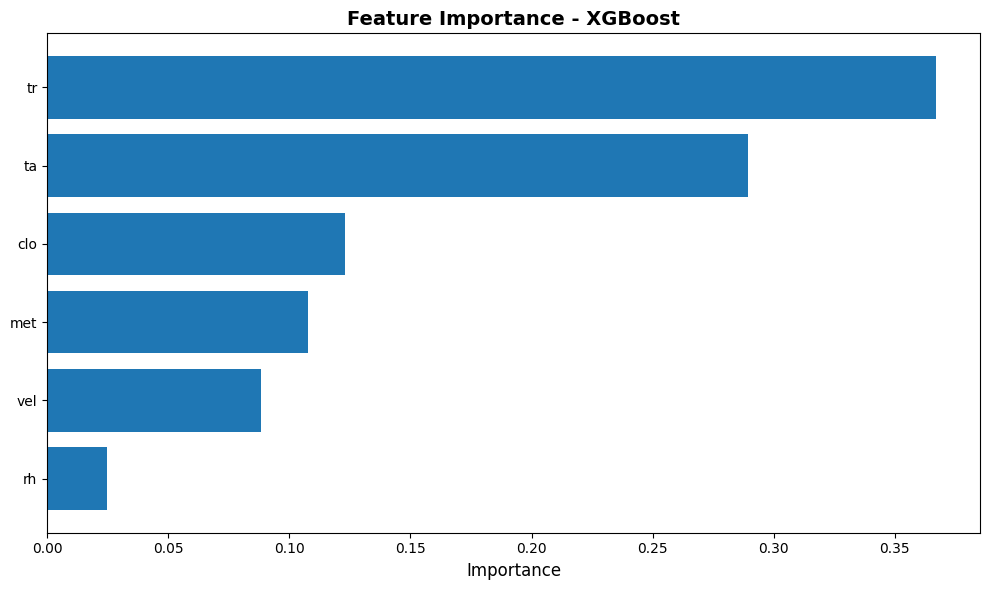

In [33]:
# 4. Visualización
fig, ax = plt.subplots(figsize=(16, 6))

train_indices = range(len(y_train))
test_indices = range(len(y_train), len(y_train) + len(y_test))

ax.plot(train_indices, y_train.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train_xgb, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

ax.plot(test_indices, y_test.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test_xgb, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

ax.axvline(x=len(y_train), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV - XGBoost', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Métricas
print("=== XGBoost Performance ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train, y_pred_train_xgb):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_xgb)):.4f}")
print(f"  R²:   {r2_score(y_train, y_pred_train_xgb):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_test_xgb):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_xgb)):.4f}")
print(f"  R²:   {r2_score(y_test, y_pred_test_xgb):.4f}")

# 6. Importancia de features
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance_xgb)

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_xgb['Feature'], feature_importance_xgb['Importance'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance - XGBoost', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
# 1. Crear y entrenar el modelo XGBoost sin met/clo
xgb_model1 = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=11,
    n_jobs=-1
)

In [35]:
# 2. Entrenar el modelo
xgb_model1.fit(X_train1, y_train1)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
# 3. Hacer predicciones
y_pred_train_xgb1 = xgb_model1.predict(X_train1)
y_pred_test_xgb1 = xgb_model1.predict(X_test1)

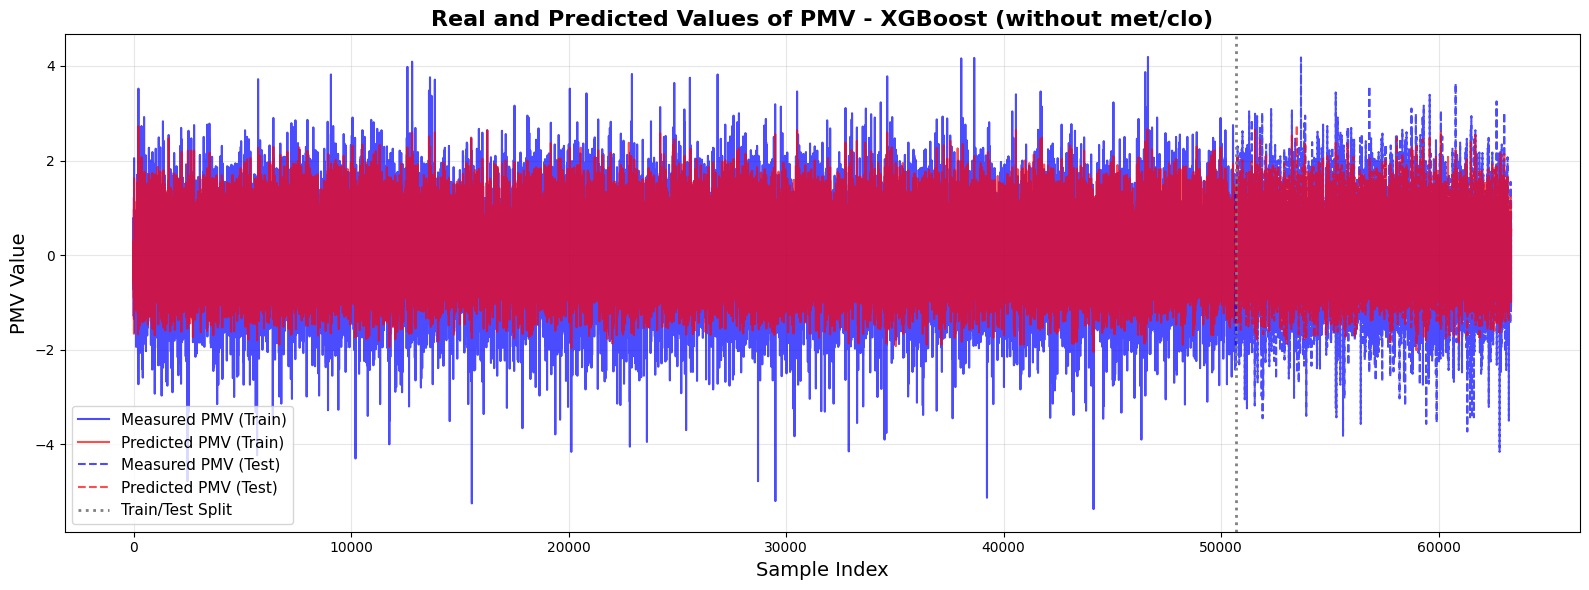

=== XGBoost Performance (without met/clo) ===

Train Set:
  MAE:  0.3082
  RMSE: 0.4224
  R²:   0.6724

Test Set:
  MAE:  0.3163
  RMSE: 0.4365
  R²:   0.6614

=== Feature Importance ===
  Feature  Importance
1      tr    0.417675
0      ta    0.409309
3     vel    0.133340
2      rh    0.039675


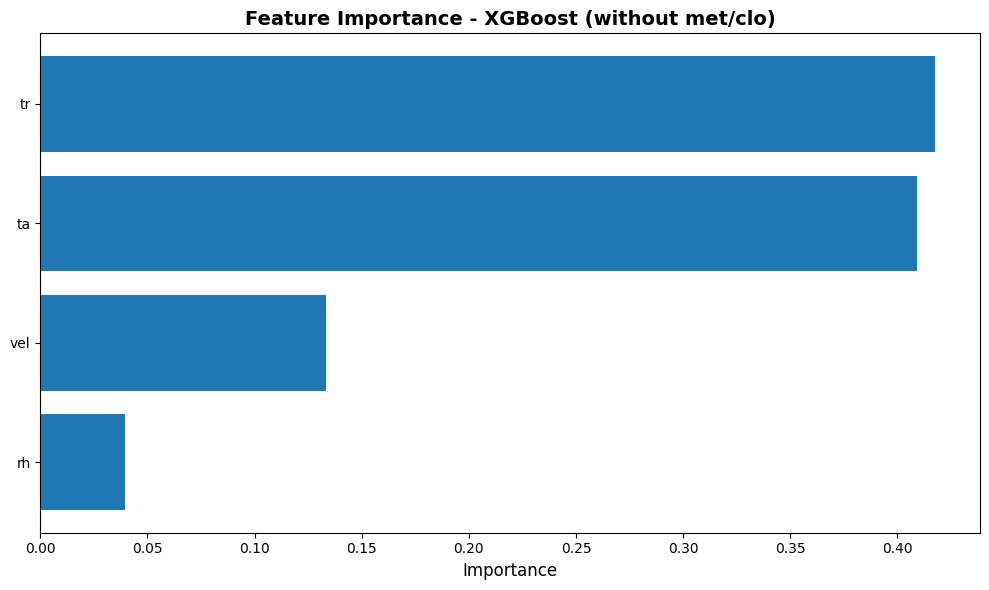

In [37]:
# 4. Visualización
fig, ax = plt.subplots(figsize=(16, 6))

train_indices = range(len(y_train1))
test_indices = range(len(y_train1), len(y_train1) + len(y_test1))

ax.plot(train_indices, y_train1.values, 'b-', label='Measured PMV (Train)', alpha=0.7, linewidth=1.5)
ax.plot(train_indices, y_pred_train_xgb1, 'r-', label='Predicted PMV (Train)', alpha=0.7, linewidth=1.5)

ax.plot(test_indices, y_test1.values, 'b--', label='Measured PMV (Test)', alpha=0.7, linewidth=1.5)
ax.plot(test_indices, y_pred_test_xgb1, 'r--', label='Predicted PMV (Test)', alpha=0.7, linewidth=1.5)

ax.axvline(x=len(y_train1), color='gray', linestyle=':', linewidth=2, label='Train/Test Split')

ax.set_xlabel('Sample Index', fontsize=14)
ax.set_ylabel('PMV Value', fontsize=14)
ax.set_title('Real and Predicted Values of PMV - XGBoost (without met/clo)', fontsize=16, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Métricas
print("=== XGBoost Performance (without met/clo) ===")
print(f"\nTrain Set:")
print(f"  MAE:  {mean_absolute_error(y_train1, y_pred_train_xgb1):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train1, y_pred_train_xgb1)):.4f}")
print(f"  R²:   {r2_score(y_train1, y_pred_train_xgb1):.4f}")

print(f"\nTest Set:")
print(f"  MAE:  {mean_absolute_error(y_test1, y_pred_test_xgb1):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test1, y_pred_test_xgb1)):.4f}")
print(f"  R²:   {r2_score(y_test1, y_pred_test_xgb1):.4f}")

# 6. Importancia de features
feature_importance_xgb1 = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': xgb_model1.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance_xgb1)

# Gráfico de importancia
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_xgb1['Feature'], feature_importance_xgb1['Importance'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance - XGBoost (without met/clo)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Modelo Inverso

Entrenando modelo inverso con 50670 datos...

=== Rendimiento del Modelo Controlador (Inverso) ===
Error promedio en la temperatura (RMSE): 0.87 °C
Precisión del modelo (R2): 0.9373


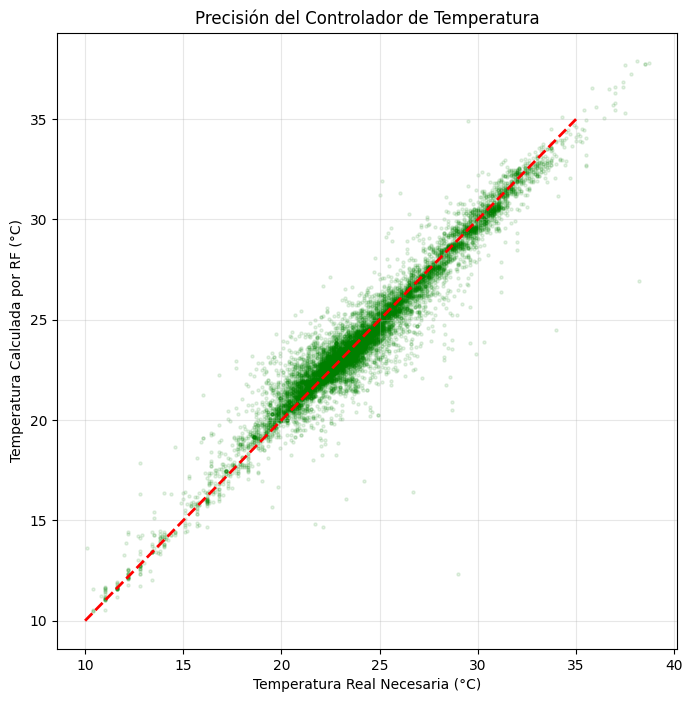

In [38]:
# --- PASO 1: PREPARACIÓN DEL MODELO INVERSO CON RANDOM FOREST ---

# 1. Reorganizar los datos para el Control
# Ahora nuestro OBJETIVO (y) es la Temperatura del Aire ('ta')
# Nuestras ENTRADAS (X) son el resto de variables + el PMV (que será nuestro objetivo de confort)

# Definimos las features para el modelo inverso
features_inversas = ["tr", "rh", "vel", "met", "clo", "pmv_ce"]
target_inverso = "ta"

X_inv = study_data[features_inversas]
y_inv = study_data[target_inverso]

# 2. Dividir en Train/Test (80/20)
X_train_inv, X_test_inv, y_train_inv, y_test_inv = train_test_split(
    X_inv, y_inv, test_size=0.2, random_state=11
)

print(f"Entrenando modelo inverso con {X_train_inv.shape[0]} datos...")

# 3. Configurar y Entrenar Random Forest
# Usamos parámetros robustos basados en tu investigación anterior
rf_controlador = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,       # Limitamos un poco la profundidad para generalizar mejor
    min_samples_leaf=5,
    random_state=11,
    n_jobs=-1
)

rf_controlador.fit(X_train_inv, y_train_inv)

# 4. Validar el "Controlador"
y_pred_inv = rf_controlador.predict(X_test_inv)

mse_inv = mean_squared_error(y_test_inv, y_pred_inv)
rmse_inv = np.sqrt(mse_inv)
r2_inv = r2_score(y_test_inv, y_pred_inv)

print("\n=== Rendimiento del Modelo Controlador (Inverso) ===")
print(f"Error promedio en la temperatura (RMSE): {rmse_inv:.2f} °C")
print(f"Precisión del modelo (R2): {r2_inv:.4f}")

# Visualización rápida: Predicho vs Real
plt.figure(figsize=(8, 8))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.1, color='green', s=5)
plt.plot([10, 35], [10, 35], 'r--', lw=2) # Línea perfecta
plt.xlabel("Temperatura Real Necesaria (°C)")
plt.ylabel("Temperatura Calculada por RF (°C)")
plt.title("Precisión del Controlador de Temperatura")
plt.grid(True, alpha=0.3)
plt.show()

## Simulación

=== REPORTE DEL SISTEMA DE CONTROL INTELIGENTE ===


,Escenario,met,clo,Setpoint Sugerido (°C)
0,Descanso en Verano,1.0,0.5,26.7
1,Ejercicio en Casa,3.0,0.3,24.3
2,Invierno Abrigado,1.1,1.2,22.1


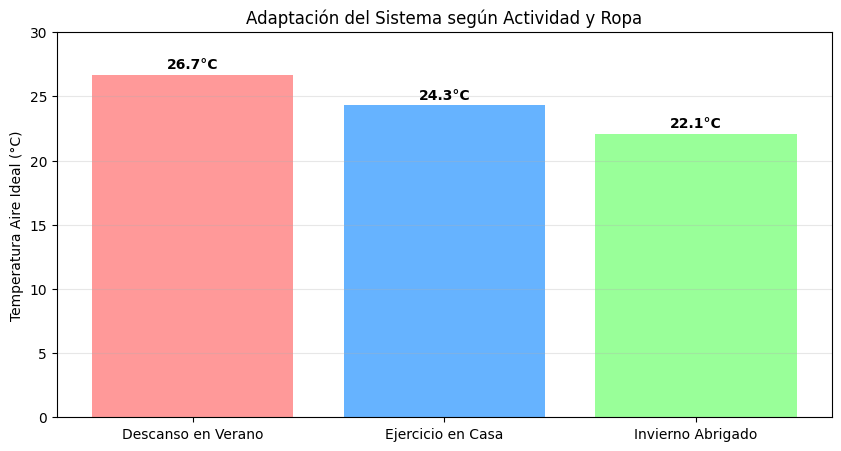

In [39]:
# --- PASO 2: SIMULADOR DE CONTROL INTELIGENTE ---

def sistema_control_smart_home(escenarios_df, modelo):
    """
    Toma un DataFrame con las condiciones de la casa y el usuario,
    y devuelve la temperatura de consigna (setpoint) ideal.
    """
    # Aseguramos el orden correcto de las columnas
    cols_modelo = ["tr", "rh", "vel", "met", "clo", "pmv_ce"]
    input_data = escenarios_df[cols_modelo]
    
    # El modelo predice la Temperatura del Aire (Ta) necesaria
    setpoints = modelo.predict(input_data)
    return setpoints

# 1. Definir Escenarios de Prueba (Casos de Uso)
# Supongamos que queremos confort total (PMV = 0)
datos_simulacion = pd.DataFrame({
    'Escenario': ['Descanso en Verano', 'Ejercicio en Casa', 'Invierno Abrigado'],
    'tr':     [28.0, 22.0, 18.0],  # Temp. Radiante (Paredes)
    'rh':     [50.0, 60.0, 40.0],  # Humedad Relativa %
    'vel':    [0.15, 0.10, 0.10],  # Velocidad del aire m/s
    'met':    [1.0,  3.0,  1.1],   # Actividad (1=Sentado, 3=Ejercicio)
    'clo':    [0.5,  0.3,  1.2],   # Ropa (0.5=Camiseta, 1.2=Suéter grueso)
    'pmv_ce': [0.0,  0.0,  0.0]    # OBJETIVO: Confort Neutro
})

# 2. Ejecutar el Control
setpoints_calculados = sistema_control_smart_home(datos_simulacion, rf_controlador)

# 3. Mostrar Resultados
resultados = datos_simulacion.copy()
resultados['Setpoint Sugerido (°C)'] = setpoints_calculados.round(1)

print("=== REPORTE DEL SISTEMA DE CONTROL INTELIGENTE ===")
display(resultados[['Escenario', 'met', 'clo', 'Setpoint Sugerido (°C)']])

# 4. Gráfico de Validación
plt.figure(figsize=(10, 5))
bars = plt.bar(resultados['Escenario'], resultados['Setpoint Sugerido (°C)'], 
               color=['#ff9999', '#66b3ff', '#99ff99'])

plt.ylabel('Temperatura Aire Ideal (°C)')
plt.title('Adaptación del Sistema según Actividad y Ropa')
plt.ylim(0, 30) # Rango típico de casa
plt.grid(axis='y', alpha=0.3)

# Poner el valor encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval}°C", ha='center', fontweight='bold')

plt.show()

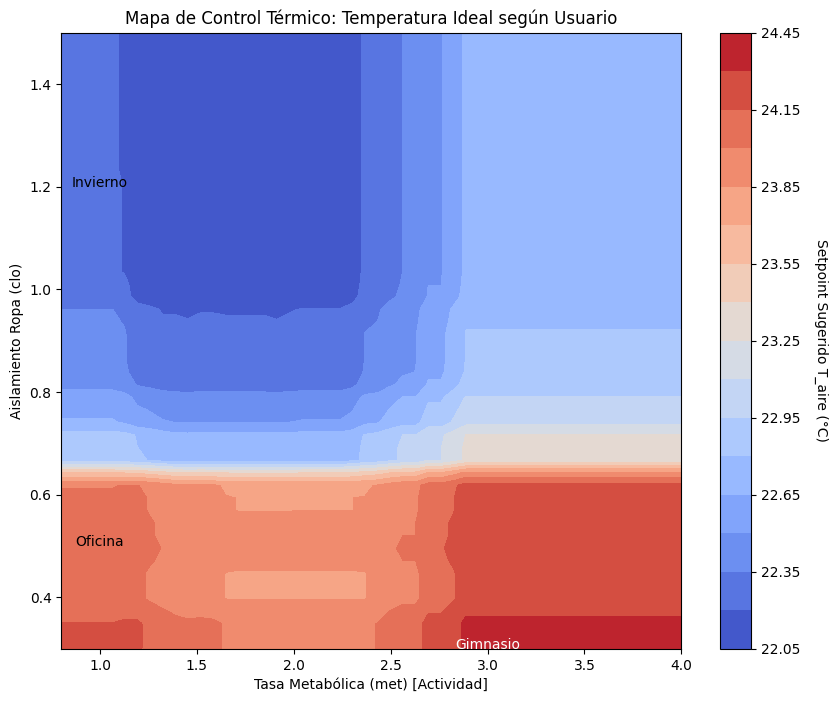

In [40]:
# --- PASO 3: MAPA DE CONTROL (HEATMAP) ---

# 1. Crear una grilla de valores simulados
met_range = np.linspace(0.8, 4.0, 50)  # De descanso a ejercicio intenso
clo_range = np.linspace(0.3, 1.5, 50)  # De ropa de playa a abrigo invernal

met_grid, clo_grid = np.meshgrid(met_range, clo_range)

# Aplanamos para pasar al modelo
sim_data = pd.DataFrame({
    'tr': 22.0,      # Asumimos pared a temp estándar
    'rh': 50.0,      # Humedad estándar
    'vel': 0.1,      # Sin corrientes de aire
    'met': met_grid.ravel(),
    'clo': clo_grid.ravel(),
    'pmv_ce': 0.0    # Objetivo Confort
})

# Aseguramos orden de columnas
sim_data = sim_data[["tr", "rh", "vel", "met", "clo", "pmv_ce"]]

# 2. Predecir Temperaturas
temp_predicha = rf_controlador.predict(sim_data)
temp_grid = temp_predicha.reshape(met_grid.shape)

# 3. Graficar el Heatmap
plt.figure(figsize=(10, 8))
contour = plt.contourf(met_grid, clo_grid, temp_grid, levels=20, cmap='coolwarm')
cbar = plt.colorbar(contour)
cbar.set_label('Setpoint Sugerido T_aire (°C)', rotation=270, labelpad=20)

plt.xlabel('Tasa Metabólica (met) [Actividad]')
plt.ylabel('Aislamiento Ropa (clo)')
plt.title('Mapa de Control Térmico: Temperatura Ideal según Usuario')
plt.grid(False) # Limpiamos la grilla para ver mejor los colores

# Anotaciones clave
plt.text(1.0, 0.5, "Oficina", color='black', ha='center')
plt.text(3.0, 0.3, "Gimnasio", color='white', ha='center')
plt.text(1.0, 1.2, "Invierno", color='black', ha='center')

plt.show()

In [41]:
import joblib
# Guardamos el modelo inverso que ya entrenaste
joblib.dump(rf_controlador, 'modelo_control_hvac.pkl')

['modelo_control_hvac.pkl']

xgboost

In [42]:
# --- ENTRENAMIENTO DEL MODELO INVERSO CON XGBOOST ---
from xgboost import XGBRegressor
import joblib
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir datos (Usando el dataset completo con clo y met)
# Features: Variables que conoceremos + el objetivo PMV
features_inv = ["tr", "rh", "vel", "met", "clo", "pmv_ce"]
target_inv = "ta" # Queremos predecir la temperatura del aire

X_inv = study_data[features_inv]
y_inv = study_data[target_inv]

# 2. Dividir
X_train, X_test, y_train, y_test = train_test_split(X_inv, y_inv, test_size=0.2, random_state=42)

# 3. Configurar XGBoost (Hiperparámetros robustos)
print("Entrenando Controlador con XGBoost...")
xgb_controlador = XGBRegressor(
    n_estimators=200,
    max_depth=6,          # Profundidad media para evitar sobreajuste extremo
    learning_rate=0.05,   # Aprendizaje suave
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_controlador.fit(X_train, y_train)

# 4. Validar
y_pred = xgb_controlador.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n=== Resultados XGBoost Inverso ===")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f} °C")

# 5. Guardar
joblib.dump(xgb_controlador, 'modelo_control_hvac_xgb.pkl')
print("Modelo guardado como 'modelo_control_hvac_xgb.pkl'")

Entrenando Controlador con XGBoost...

=== Resultados XGBoost Inverso ===
R²: 0.9551
RMSE: 0.7385 °C
Modelo guardado como 'modelo_control_hvac_xgb.pkl'
